In [1]:
from datasets import load_dataset

dataset = load_dataset("eriktks/conll2003")

conll2003.py:   0%|          | 0.00/9.57k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/12.3k [00:00<?, ?B/s]

The repository for eriktks/conll2003 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/eriktks/conll2003.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N]  y


Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [2]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})


### توضیح کد:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
برای ساخت کلاس vocab ابتدا ورودی‌ها تعریف می‌شوند. که شامل داده‌های آموزش، cutoff و special token ها هستند. سپس مقادیر اولیه تعریف می‌شوند: مقدار cutoff، special token ها، دیکشنری‌ای برای ذخیره id توکن‌ها (vocab)، دیکشنری‌ای برای ذخیره خود توکن‌ها (id_to_token )، توکن‌های موجود در داده‌های آموزش و در نهایت تابع build_vocab برای ساختن vocab.
<br>
برای ساخت vocab تابع build_vocab تعریف شده‌است. ابتدا در این تابع ایندکس special tokens به عنوان id (از 0 تا 3) و خود special token ها  در دو دیکشنری vocab و id_to_token ذخیره می‌شوند. سپس به کمک تابع Counter فراوانی سایر توکن‌ها محاسبه می‌شود. به کمک یک حلقه for بر روی این فراوانی بررسی می‌شود که اگر مقدار فراوانی توکن بیشتر از مقدار cutoff باشد و آن توکن در vocab موجود نباشد، آن توکن و id آن در دو دیکشنری مربوطه ذخیره می‌شوند. id توکن براساس طول دیکشنری تا آن لحظه تعریف می‌شود
<br>.
تابع vocab_size اندازه vocab، تابع id_into_token با گرفتن id توکن به عنوان ورودی در صورت وجود آن توکن و در غیر اینصورت توکن "<unk>" را بر می‌گرداند.  درنهایت تابع token_into_id توکن را به عنوان ورودی دریافت و id آن را در صورت وجود بر می‌گرداند و در غیراینصورت id توکن "<unk>" را بر می‌گردان
<br>د.
در بخش بعد vocab به کمک داده‌های آموزش تعریف می‌شود. که اندازه آن 4917 است. همچنین id توکن 'quick' بااستفاده از تابع token_into_id و توکن id 0 به کمک تابع id_into_token نشان داده شده‌است.



In [2]:
# پاسخ ج:

# write your code here
from collections import Counter

class Vocab:
    def __init__(self, x_train, cutoff=5, special_tokens=["<pad>", "<unk>", "<s>", "</s>"]):

        self.cutoff = cutoff
        self.special_tokens = special_tokens
        self.vocab = {}
        self.id_to_token = {}

        self.tokens = [token for tokens in x_train['tokens'] for token in tokens]

        self.build_vocab()

    def build_vocab(self):
        for idx, token in enumerate(self.special_tokens):
            self.vocab[token] = idx
            self.id_to_token[idx] = token

        frequency = Counter(self.tokens)
        
        for token, freq in frequency.items():
            if freq >= self.cutoff and token not in self.vocab:
                token_id = len(self.vocab)
                self.vocab[token] = token_id
                self.id_to_token[token_id] = token

    def vocab_size(self):
        return len(self.vocab)

    def id_into_token(self, token_id):
        return self.id_to_token.get(token_id, "<unk>")

    def token_into_id(self, token):
        return self.vocab.get(token, self.vocab.get("<unk>"))



In [17]:
# پاسخ د:

# write your code here
train_dataset = dataset["train"]

vocab = Vocab(train_dataset, cutoff=5)

print("Vocabulary size:", vocab.vocab_size())

encoded = vocab.token_into_id('quick')
decoded = vocab.id_into_token(0)
print("id of 'quick':", encoded)
print("token of 0:", decoded)


Vocabulary size: 4917
id of 'quick': 2387
token of 0: <pad>


<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">



*بخش اول:*

---

پاسح الف:

---

# پاسخ خود را اینجا بنویسید:

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
برتری Collate_fn نسبت به پد کردن تمام جملات به اندازه بزرگترین جمله batch در کاهش حجم داده‌ها و مصرف حافظه می‌شود. Collate_fn  تنها جملات هر batch را به اندازه طولانی‌ترین جمله آن batch پد می‌کند، که منجر به استفاده بهینه‌تر از حافظه می‌شود. که با کاهش حجم داده‌ها سرعت پردازش نیز افزایش می‌یابد. علاوه بر این  امکان مدیریت داده‌ها با طول متغیر را فراهم می‌کند. این ویژگی به خصوص در کار با داده‌های متنی و توالی‌ها مفید است، زیرا طول جملات می‌تواند بسیار متغیر باشد.
---

### توضیح کد:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
برای آماده‌سازی dataset کلاس CustomDataset تعریف شده که ورودی آن dataset است. ابتدا مقادیر اولیه تعریف می‌شوند که  dataset و طول آن هستند. تابع __len__ طول دیتاست را برمی‌گرداند و تابع __getitem__ با گرفتن ایندکس، id توکن‌ها و ner tag سطر مربوطه را برمی‌گرداند. در این تابع توکن‌ها به کمک تابع token_into_id کلاس vocab به id تبدیل می‌شوند.
    <br>
در قسمت بعد کلاس Collate_fn تعریف می‌شود. با فراخواندن این کلاس در dataloader دو لیست از توکن‌ها و لیبل‌های هر batch ایجاد می‌شود. سپس به کمک تابع pad_sequence طول تمام توکن‌ها و لیبل‌های هر سطر آن batch به طول بلندترین سطر با گذاشتن id توکن "<pad>" برای توکن‌ها و مقدار 9 برای لیبل‌ها ( مقدار ner tag ها از 0 تا 8 متغیر است)  به طول بلندترین سطر موجود در آن batch تبدیل می‌شود
    <br>.
در بخش بعد dataset ها و dataloader ها به کمک کلاس‌های تعریف شده ایجاد می‌شوند. همچنین ابعاد اولین batch داده‌های train و validation نمایش داده می‌شود.


In [18]:
# پاسخ ب:

# write your code here
from torch.utils.data import Dataset, DataLoader
import torch
from torch.nn.utils.rnn import pad_sequence


class CustomDataset(Dataset):
    def __init__(self, data):

        self.dataset = data
        self.len = len(self.dataset)

    def __len__(self):
        return self.len

    def __getitem__(self, idx):

        tokens = self.dataset[idx]['tokens']
        token_id = []

        for t in tokens:
            token_id.append(vocab.token_into_id(t))

        ner_tags = self.dataset[idx]['ner_tags']
        return token_id, ner_tags



class Collate_fn:
    def __call__(self, batch):
        tokens_batch = [torch.tensor(item[0]) for item in batch]  
        labels_batch = [torch.tensor(item[1]) for item in batch] 


        padded_tokens = pad_sequence(tokens_batch, batch_first=True, padding_value=vocab.token_into_id("<pad>"))
        padded_labels = pad_sequence(labels_batch, batch_first=True, padding_value=9)

        return padded_tokens, padded_labels


In [26]:
train_dataset = CustomDataset(dataset["train"])
val_dataset = CustomDataset(dataset["validation"])
test_dataset = CustomDataset(dataset["test"])

train_loader = DataLoader(train_dataset, batch_size=32, collate_fn=Collate_fn())
val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=Collate_fn())
test_loader = DataLoader(test_dataset, batch_size=32, collate_fn=Collate_fn())


train_tokens, train_labels = next(iter(train_loader))
val_tokens, val_labels = next(iter(val_loader))

print("Train batch tokens shape:", train_tokens.shape)  
print("Train batch labels shape:", train_labels.shape)  
print("Validation batch tokens shape:", val_tokens.shape)
print("Validation batch labels shape:", val_labels.shape)

Train batch tokens shape: torch.Size([32, 47])
Train batch labels shape: torch.Size([32, 47])
Validation batch tokens shape: torch.Size([32, 41])
Validation batch labels shape: torch.Size([32, 41])


<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">



*بخش دوم:*

---

برای قسمت های (الف) تا (ج) این بخش کد را ساختار کد در این بخش بر عهده خود شماست

---

### توضیح کد:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
ابتدا برای آموزش مدل‌ها تابع train تعریف می‌شود. در این تابع ابتدا مدل به device منتقل می‌شود. سپس متغیرهایی برای ذخیره مقادیر loss و دقت همه ایپاک‌ها تعریف می‌شوند. در هر ایپاک مدل در حالت train قرار می‌گیرد و متغیرهایی برای ذخیره loss و دقت هر ایپاک تعریف می‌شوند. سپس توکن‌ها و لیبل‌ها در هر batch به device منتقل می‌شوند و مقدار گرادیان‌ها برابر 0 می‌شود. توکن‌ها به مدل داده می‌شوند تا خروجی حساب شود. همچنین ابعاد output  و label برای محاسبه loss تغییر می‌کنند. در گام بعد mask تعریف می‌شود. که برابر با ایندکس لیبل‌هایی است که برابر با لیبل pad (که همان 9 است) نیستند، است. به کمک mask، active_outputs ها و active_labels ها برای محاسبه loss تعریف می‌شوند و loss محاسبه می‌شود. در گام بعد backprobgation بر روی loss انجام و مقدار پارامترها آپدیت می‌شوند. در نهایت ایندکس بیشترین مقدار output به عنوان پیش‌بینی مدل تعریف می‌شود و باتوجه به mask تعداد موارد درست پیش‌بینی شده برای این iteration تعیین می‌شود. پس از اتمام تمام iteration ها مقدار loss و دقت برای آن ایپاک محاسبه و نمایش داده می‌شود. قسمت ارزیابی تقریبا مشابه قسمت آموزش است. در این قسمت مدل در حالت eval قرار می‌گیرد و محاسبات گرادیان انجام نخواهد شد. 
<br>
در نهایت نمودار مقادیر دقت و loss آموزش و ارزیابی مدل در تمام ایپاک‌ها نمایش داده می‌شود
    <br>.
در بخش بعد تابعی برای تست مدل تعریف شده‌است. این تابع تقریبا مشابه بخش ارزیابی تابع train است با این تفاوت که در انتها مقادیر پیش‌بینی و لیبل‌ها برای محاسبه classification_report به cpu منتقل و به آرایه numpy تبدیل می‌شوند.


In [22]:
import torch
import matplotlib.pyplot as plt

def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs, pad_token_id):

    model.to(device)
    
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):

        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for tokens, labels in train_loader:
            tokens = tokens.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(tokens)
            
            outputs = outputs.view(-1, outputs.size(-1))  
            labels = labels.view(-1)  
             
            mask = labels != pad_token_id
            active_outputs = outputs[mask]
            active_labels = labels[mask]

            loss = criterion(active_outputs, active_labels)
            running_loss += loss.item()
            
            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, dim=-1)
            correct_train += (preds[mask] == labels[mask]).sum().item()
            total_train += mask.sum().item()

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_accuracy = 100 * correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss}, Train Accuracy: {epoch_train_accuracy}%')

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for tokens, labels in val_loader:
                tokens = tokens.to(device)
                labels = labels.to(device)

                outputs = model(tokens)

                outputs = outputs.view(-1, outputs.size(-1))  
                labels = labels.view(-1) 
             
                mask = labels != pad_token_id
                active_outputs = outputs[mask]
                active_labels = labels[mask]

                loss = criterion(active_outputs, active_labels)
                val_running_loss += loss.item()


                preds = torch.argmax(outputs, dim=-1)
                correct_val += (preds[mask] == labels[mask]).sum().item()
                total_val += mask.sum().item()

        epoch_val_loss = val_running_loss / len(val_loader)
        epoch_val_accuracy = 100 * correct_val / total_val
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_accuracy)

        print(f'Validation Loss: {epoch_val_loss}, Validation Accuracy: {epoch_val_accuracy}%')


    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train')
    plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train')
    plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [23]:
from sklearn.metrics import classification_report

def test_model(model, test_loader, pad_token_id):
    
    model.to(device)
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for tokens, labels in test_loader:
            tokens = tokens.to(device)
            labels = labels.to(device)

            outputs = model(tokens)
            outputs = outputs.view(-1, outputs.size(-1))  
            labels = labels.view(-1)  

            mask = labels != pad_token_id 
            active_outputs = outputs[mask]  
            active_labels = labels[mask]  
            
            pred = torch.argmax(active_outputs, dim=-1)

            all_labels.extend(active_labels.cpu().numpy())
            all_predictions.extend(pred.cpu().numpy())

 
    report = classification_report(all_labels, all_predictions, zero_division=0)
    print("\nClassification Report:\n", report)


### توضیح کد:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
برای تعریف encoder با استفاده از یک لایه RNN دو طرفه کلاس Bi_RNN تعریف شده‌است. ورودی‌ها اندازه vocab، hidden_size، embedding_size و تعداد کلاس‌ها هستند. ابتدا هر لایه این encoder تعریف می‌شود. لایه اول لایه embedding با ابعادی به اندازه سایز vocab در embedding_size است. لایه بعد یک شبکه RNN دوطرفه است که اندازه ورودی آن به اندازه embedding_size و اندازه لایه hidden آن به اندازه hidden_size تعریف می‌شود. در نهایت یک لایه linear تعریف می‌شود. از آنجا که RNN دوطرفه است، اندازه ورودی این لایه دو برابر hidden_size لایه RNN و اندازه خروجی آن به اندازه تعداد کلاس‌ها است. سپس تابع forward تعریف می‌شود که ورودی را دریافت و به لایه embedding میدهد. خروجی لایه embedding به لایه RNN دوطرفه داده می‌شود. در نهایت خروجی این لایه ( نه لایه hidden آن) به لایه linear برای تعیین کلاس داده می‌شود.
    <br>
در قسمت بعد مقادیر اولیه و مدل تعریف می‌شوند و به کمک تابع train و به ازای بهینه‌ساز Adam و تابع هزینه cross entropy مدل آموزش داده می‌شود
        <br>.
کد encoder های دو بخش دیگر مشابه این بخش هستند و تنها در لایه میانی تفاوت دارند.


In [20]:
import torch.nn as nn

class Bi_RNN(nn.Module):
    def __init__(self, vocab_size, hidden_size, embedding_size,num_classes):
        super(Bi_RNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.birnn = nn.RNN(embedding_size, hidden_size, bidirectional=True, batch_first=True)
        self.linear = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):

        x = self.embedding(x)
        output, _ = self.birnn(x)
        logits = self.linear(output)

        return logits
        


Epoch [1/10], Train Loss: 0.737753653852163, Train Accuracy: 83.18493672067223%
Validation Loss: 0.5503889138207716, Validation Accuracy: 85.52237062419688%
Epoch [2/10], Train Loss: 0.4594343607409397, Train Accuracy: 87.54450670608631%
Validation Loss: 0.3934724455808892, Validation Accuracy: 88.47396908220085%
Epoch [3/10], Train Loss: 0.32334900002476835, Train Accuracy: 90.68367211633378%
Validation Loss: 0.3057230037144002, Validation Accuracy: 90.74802383084771%
Epoch [4/10], Train Loss: 0.24466133788058317, Train Accuracy: 92.81262738126225%
Validation Loss: 0.2569834530243979, Validation Accuracy: 92.10311124956193%
Epoch [5/10], Train Loss: 0.19409109728202936, Train Accuracy: 94.22996645729076%
Validation Loss: 0.22759684759612178, Validation Accuracy: 92.97924535648923%
Epoch [6/10], Train Loss: 0.15909677635504946, Train Accuracy: 95.18468134426213%
Validation Loss: 0.20791172978523023, Validation Accuracy: 93.57306958451774%
Epoch [7/10], Train Loss: 0.13333535226325002, 

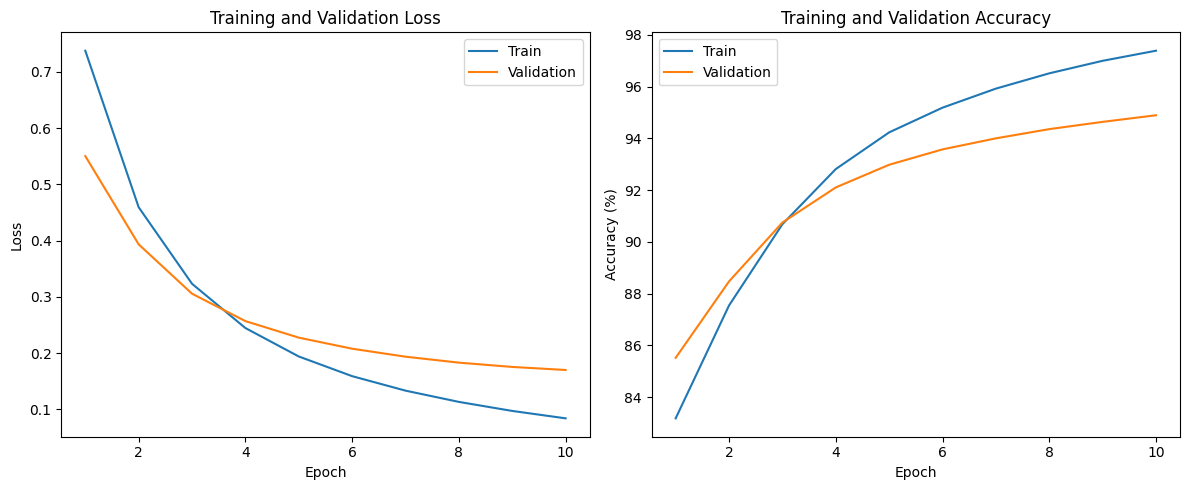

In [13]:
vocab_size = vocab.vocab_size()
embedding_size = 64
hidden_size = 64
num_classes = 10
num_epochs = 10
pad_token_id = 9

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


birnn = Bi_RNN(vocab_size, embedding_size, hidden_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(birnn.parameters(), lr=0.001)

train_model(birnn, criterion, optimizer, train_loader, val_loader, num_epochs, pad_token_id)


In [14]:
test_model(birnn, test_loader, pad_token_id)



Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97     38323
           1       0.92      0.57      0.70      1617
           2       0.91      0.68      0.78      1156
           3       0.75      0.64      0.69      1661
           4       0.65      0.72      0.68       835
           5       0.86      0.77      0.81      1668
           6       0.72      0.60      0.65       257
           7       0.78      0.63      0.70       702
           8       0.69      0.62      0.65       216

    accuracy                           0.93     46435
   macro avg       0.80      0.69      0.74     46435
weighted avg       0.93      0.93      0.93     46435



In [8]:
import torch.nn as nn

class Bi_LSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size, embedding_size,num_classes):
        super(Bi_LSTM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.bilstm = nn.LSTM(embedding_size, hidden_size, bidirectional=True, batch_first=True)
        self.linear = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):

        x = self.embedding(x)
        output, _ = self.bilstm(x)
        logits = self.linear(output)

        return logits

Epoch [1/10], Train Loss: 0.7850808124471634, Train Accuracy: 82.54846012935798%
Validation Loss: 0.5847691585328064, Validation Accuracy: 84.94996300767104%
Epoch [2/10], Train Loss: 0.47810991537801767, Train Accuracy: 87.47182265090535%
Validation Loss: 0.3835694756285817, Validation Accuracy: 89.02496008722402%
Epoch [3/10], Train Loss: 0.311729699271415, Train Accuracy: 91.17183394640043%
Validation Loss: 0.2888959236077818, Validation Accuracy: 91.34574198824033%
Epoch [4/10], Train Loss: 0.22548333174445093, Train Accuracy: 93.36659774777651%
Validation Loss: 0.24129415301642582, Validation Accuracy: 92.56648884389237%
Epoch [5/10], Train Loss: 0.17357931473209673, Train Accuracy: 94.76920356937644%
Validation Loss: 0.2112301804454011, Validation Accuracy: 93.51855457342003%
Epoch [6/10], Train Loss: 0.13782038807482852, Train Accuracy: 95.81330019988116%
Validation Loss: 0.191618214009841, Validation Accuracy: 94.1045909427203%
Epoch [7/10], Train Loss: 0.11159018042830407, Tra

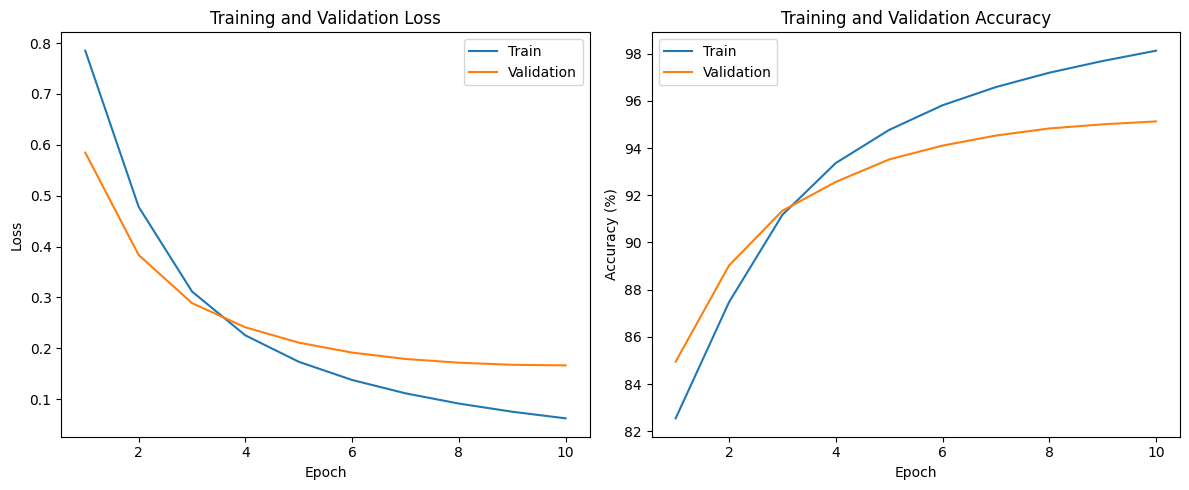

In [10]:
vocab_size = vocab.vocab_size()
embedding_size = 64
hidden_size = 64
num_classes = 10
num_epochs = 10
pad_token_id = 9

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


bilstm = Bi_LSTM(vocab_size, embedding_size, hidden_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(bilstm.parameters(), lr=0.001)

train_model(bilstm, criterion, optimizer, train_loader, val_loader, num_epochs, pad_token_id)

In [11]:
test_model(bilstm, test_loader, pad_token_id)


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97     38323
           1       0.88      0.64      0.74      1617
           2       0.89      0.72      0.80      1156
           3       0.74      0.64      0.69      1661
           4       0.64      0.71      0.67       835
           5       0.85      0.77      0.81      1668
           6       0.72      0.63      0.67       257
           7       0.79      0.62      0.69       702
           8       0.65      0.59      0.62       216

    accuracy                           0.93     46435
   macro avg       0.79      0.70      0.74     46435
weighted avg       0.93      0.93      0.93     46435



In [29]:
class Bi_GRU(nn.Module):
    def __init__(self, vocab_size, hidden_size, embedding_size,num_classes):
        super(Bi_GRU, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.bigru = nn.GRU(embedding_size, hidden_size, bidirectional=True, batch_first=True)
        self.linear = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):

        x = self.embedding(x)
        output, _ = self.bigru(x)
        logits = self.linear(output)

        return logits

Epoch [1/10], Train Loss: 0.7722202476309209, Train Accuracy: 82.45514951797702%
Validation Loss: 0.5747961472062504, Validation Accuracy: 85.08235660605116%
Epoch [2/10], Train Loss: 0.4679491239046181, Train Accuracy: 87.67317712809583%
Validation Loss: 0.3764500419298808, Validation Accuracy: 89.1593006502862%
Epoch [3/10], Train Loss: 0.3044111308788113, Train Accuracy: 91.32947976878613%
Validation Loss: 0.2806939164213106, Validation Accuracy: 91.61052918500059%
Epoch [4/10], Train Loss: 0.21701185426893294, Train Accuracy: 93.59201654053363%
Validation Loss: 0.22992629104969547, Validation Accuracy: 93.01429072076633%
Epoch [5/10], Train Loss: 0.164540170452182, Train Accuracy: 95.03047328124309%
Validation Loss: 0.20006584217224052, Validation Accuracy: 93.85927339278065%
Epoch [6/10], Train Loss: 0.12924635292567602, Train Accuracy: 96.05492557250972%
Validation Loss: 0.181453921649532, Validation Accuracy: 94.34017366924964%
Epoch [7/10], Train Loss: 0.1034836491224078, Train

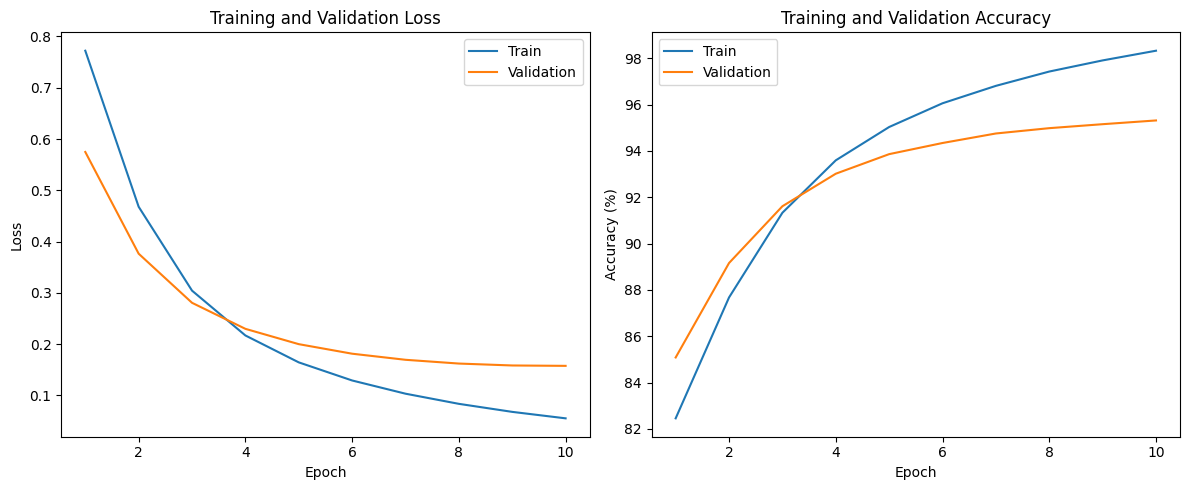

In [30]:
bigru = Bi_GRU(vocab_size, embedding_size, hidden_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(bigru.parameters(), lr=0.001)

train_model(bigru, criterion, optimizer, train_loader, val_loader, num_epochs, pad_token_id)

In [31]:
test_model(bigru, test_loader, pad_token_id)


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97     38323
           1       0.86      0.69      0.76      1617
           2       0.87      0.78      0.82      1156
           3       0.73      0.66      0.69      1661
           4       0.62      0.74      0.68       835
           5       0.87      0.77      0.82      1668
           6       0.72      0.47      0.57       257
           7       0.74      0.64      0.69       702
           8       0.62      0.61      0.62       216

    accuracy                           0.93     46435
   macro avg       0.78      0.70      0.73     46435
weighted avg       0.93      0.93      0.93     46435



<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">



*بخش دوم:*

---

پاسح تشریحی قسمت (د):

---

# پاسخ خود را اینجا بنویسید:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">
همانطور که مشاهده می‌شود تفاوت بسیار ناچیزی بین معیارهای خروجی این سه مدل است. دو مدل LSTM و GRU برای رفع مشکل vanishing gradient در RNN ایجاد شدند. اما از آنجا که تعداد توکن‌های هر سطر داده نسبتا کم است (طول sequence کوتاه است)، مشکل vanishing gradient ایجاد نمی‌شود و در نتیجه خروجی هر سه شبکه تقریبا برابر است.
---

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">



#**سوال دوم:**

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">



*بخش مجموعه داده:*

---

برای قسمت های (الف) تا (د) این بخش کد را ساختار کد در این بخش بر عهده خود شماست

---

### توضیح کد:

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">
ابتدا دیتاست load می‌شود و اندازه 30% داده های آموزش و 10% داده‌های ارزیابی تعیین می‌شود تا براساس این مقادیر به صورت رندم داده آموزش و ارزیابی انتخاب شود. در نهایت اندازه نهایی دو مجموعه داده نمایش داده می‌شود.
<br>
در بخش بعد تابع preprocess_text برای تبدیل حروف بزرگ به کوچک، حذف punctuation ها و توکن کردن متن بر اساس فاصله تعریف می‌شود. این تابع به کمک map پیش‌پردازش متن را بر روی ستون‌های document  وsummary  در دیتاست‌ها اعمال می‌شود  و توکن‌های ایجاد شده در دو ستون جدید doc_tokens و summary_tokens ذخیره می‌شوند
<br>.
در قسمت بعد کلاس vocab تعریف شده که کامل مشابه کلاس vocab سوال قبل است. که جزئیات کد در آنجا بیان شده‌اس
<br>ت.
در بخش بعد ماتریس امبدینگ با استفاده از EmbeddingGlove ایجاد می‌شود. ابتدا فایل امبدینگ‌های Glove خوانده شده و سپس امبدینگ‌های هر کلمه در دیکشنری‌ای ذخیره می‌شوند.در گام بعد embedding_matrix با ابعاد vocab_size در embedding_dim با مقادیر 0 مقداردهی اولیه می‌شود. با iterate بر روی توکن‌های واژگان بررسی می‌شود اگر آن توکن در دیکشنری امبدینگ‌های Glove حضور داشته باشد امبدینگ Glove برای آن توکن ذخیره می‌شود و در غیراینصورت امبدینگ آن توکن برابر با بردار 0 به اندازه embedding_dim خواهد بود. در نهایت برای 3 کلمه رندم در واژگان 10 درایه ابتدایی از بردار امبدینگ نمایش داده شده‌است.


In [1]:
from datasets import load_dataset

dataset = load_dataset("xsum")

train_size = int(len(dataset['train']) * 0.3)
val_size = int(len(dataset['validation']) * 0.1)
    
train_data = dataset['train'].shuffle(seed=42).select(range(train_size))
val_data = dataset['validation'].shuffle(seed=42).select(range(val_size))
    
print(f"Train dataset size: {len(train_data)}")
print(f"Validation dataset size: {len(val_data)}")

xsum.py:   0%|          | 0.00/5.76k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.24k [00:00<?, ?B/s]

The repository for xsum contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/xsum.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N]  y


(…)SUM-EMNLP18-Summary-Data-Original.tar.gz:   0%|          | 0.00/255M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/204045 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11332 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11334 [00:00<?, ? examples/s]

Train dataset size: 61213
Validation dataset size: 1133


In [2]:
import re

def preprocess_text(text):

    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    tokens = text.split()
    
    return tokens

train_data = train_data.map(lambda x: {"doc_tokens": preprocess_text(x["document"])})
val_data = val_data.map(lambda x: {"doc_tokens": preprocess_text(x["document"])})
test_data = dataset['test'].map(lambda x: {"doc_tokens": preprocess_text(x["document"])})

train_data = train_data.map(lambda x: {"summary_tokens": preprocess_text(x["summary"])})
val_data = val_data.map(lambda x: {"summary_tokens": preprocess_text(x["summary"])})
test_data = dataset['test'].map(lambda x: {"summary_tokens": preprocess_text(x["summary"])})

Map:   0%|          | 0/61213 [00:00<?, ? examples/s]

Map:   0%|          | 0/1133 [00:00<?, ? examples/s]

Map:   0%|          | 0/11334 [00:00<?, ? examples/s]

Map:   0%|          | 0/61213 [00:00<?, ? examples/s]

Map:   0%|          | 0/1133 [00:00<?, ? examples/s]

Map:   0%|          | 0/11334 [00:00<?, ? examples/s]

In [3]:
from collections import Counter

class Vocab:
    def __init__(self, x_train, cutoff=5, special_tokens=["<pad>", "<unk>", "<s>", "</s>"]):

        self.cutoff = cutoff
        self.special_tokens = special_tokens
        self.vocab = {}
        self.id_to_token = {}

        self.tokens = [token for tokens in x_train['doc_tokens'] for token in tokens]

        self.build_vocab()

    def build_vocab(self):
        for idx, token in enumerate(self.special_tokens):
            self.vocab[token] = idx
            self.id_to_token[idx] = token

        frequency = Counter(self.tokens)
        
        for token, freq in frequency.items():
            if freq >= self.cutoff and token not in self.vocab:
                token_id = len(self.vocab)
                self.vocab[token] = token_id
                self.id_to_token[token_id] = token

    def vocab_size(self):
        return len(self.vocab)

    def id_into_token(self, token_id):
        return self.id_to_token.get(token_id, "<unk>")

    def token_into_id(self, token):
        return self.vocab.get(token, self.vocab.get("<unk>"))


vocab = Vocab(train_data, cutoff=10)

In [4]:
import torch
import numpy as np

embeddings_dict = {}

with open('/kaggle/input/glove-embedding/glove.6B.100d.txt', 'r') as file:
    for line in file:

        values = line.split()
        word = values[0]
        vector = [float(x) for x in values[1:]]
        embeddings_dict[word] = vector


vocab_size = vocab.vocab_size()
embedding_dim = 100

embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for token, idx in vocab.vocab.items():
    if token in embeddings_dict: 
        embedding_matrix[idx] = embeddings_dict[token]
    else: 
        embedding_matrix[idx] = np.zeros(embedding_dim)

for i in np.random.randint(1,vocab_size, 3):
    print(f"Embedding of '{i}': {embedding_matrix[i][:10]}")

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)
print("Embedding Matrix Shape:", embedding_matrix.shape)  


Embedding of '47616': [-0.52875   0.054369 -0.50831  -1.2324   -0.50593  -0.043136 -0.41266
  0.46012  -0.67522  -0.64772 ]
Embedding of '18312': [-0.7093  -0.30444 -0.30056  0.19443 -0.31214 -0.81183 -0.70271 -0.40327
 -0.14923 -0.41444]
Embedding of '23824': [ 0.80877  -1.1517   -0.011616  0.19531  -0.48058   0.39475  -0.054793
  0.041613 -0.040106  0.98475 ]
Embedding Matrix Shape: torch.Size([47939, 100])


<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">



*بخش اول:*

---


### توضیح کد:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">
برای آماده‌سازی dataset کلاس CustomDataset تعریف شده که ورودی آن dataset است. ابتدا مقادیر اولیه تعریف می‌شوند که  dataset و طول آن هستند. تابع __len__ طول دیتاست را برمی‌گرداند و تابع __getitem__ با گرفتن ایندکس، id توکن‌های دو ستون doc_tokens و summary_tokens برای سطر مربوطه را برمی‌گرداند. در این تابع توکن‌ها به کمک تابع token_into_id کلاس vocab به id تبدیل می‌شوند.
    <br>
در قسمت بعد کلاس Collate_fn تعریف می‌شود. با فراخواندن این کلاس در dataloader دو لیست از توکن‌ها و لیبل‌های هر batch ایجاد می‌شود. سپس به کمک تابع pad_sequence طول تمام توکن‌ها و لیبل‌های هر سطر آن batch به طول بلندترین سطر با گذاشتن id توکن "<pad>" برای توکن‌ها و مقدار 9 برای لیبل‌ها ( مقدار ner tag ها از 0 تا 8 متغیر است)  به طول بلندترین سطر موجود در آن batch تبدیل می‌شود
    <br>.
در بخش بعد dataset ها و dataloader ها به کمک کلاس‌های تعریف شده ایجاد می‌شوند. همچنین ابعاد اولین batch داده‌های trion نمایش داده می‌شود.



In [5]:
from torch.utils.data import Dataset, DataLoader
import torch
from torch.nn.utils.rnn import pad_sequence


class CustomDataset(Dataset):
    def __init__(self, data):

        self.dataset = data
        self.len = len(self.dataset)

    def __len__(self):
        return self.len

    def __getitem__(self, idx):

        doc_token = self.dataset[idx]['doc_tokens']
        summary_token = self.dataset[idx]['summary_tokens']

        doc_token_id = []
        for t in doc_token:
            doc_token_id.append(vocab.token_into_id(t))

        summary_token_id = []
        for t in summary_token:
            summary_token_id.append(vocab.token_into_id(t))

        return doc_token_id, summary_token_id



class Collate_fn:
    def __call__(self, batch):
        tokens_batch = [torch.tensor(item[0]) for item in batch]  
        summary_batch = [torch.tensor(item[1]) for item in batch] 

        padded_tokens = pad_sequence(tokens_batch, batch_first=True, padding_value=0.0)
        padded_summary = pad_sequence(summary_batch, batch_first=True, padding_value=0.0)

        return padded_tokens, padded_summary

In [6]:
train_dataset = CustomDataset(train_data)
val_dataset = CustomDataset(val_data)
test_dataset = CustomDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=32, collate_fn = Collate_fn())
val_loader = DataLoader(val_dataset, batch_size=32, collate_fn = Collate_fn())
test_loader = DataLoader(test_dataset, batch_size=32, collate_fn = Collate_fn())

train_tokens = next(iter(train_loader))

print("Train batch document tokens shape:", train_tokens[0].shape)  
print("Train batch summary tokens shape:", train_tokens[1].shape)

Train batch document tokens shape: torch.Size([32, 950])
Train batch summary tokens shape: torch.Size([32, 52])


<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">



*بخش دوم:*

---

برای قسمت های (الف) تا (ج) این بخش کد را ساختار کد در این بخش بر عهده خود شماست

---

### توضیح کد:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">
ابتدا کلاس encoder تعریف می‌شود که از یک لایه امبدینگ pretrain و یک لایه GRU دو طرفه تشکیل شده است. این لایه امبدینگ از ماتریس امبدینگ تعریف شده در بخش قبل استفاده  می‌کند و مقدار freez برابر با false است تا امبدینگ‌ها در طول آموزش تغییر کنند.
    <br>
در بخش بعد کلاس Attention تعریف می‌شود که ورودی آن state hidden، decoder در لحظه قبل و خروجی encoder (encoder_outputs ) است. state hidden، unsqueeze می‌شود تا امکان ضرب ماتریسی encoder_outputs و state hidden ایجاد شود. حاصل این ضرب از یک تابع softmax عبور داده می‌شود و به عنوان attention_weights بر گردانده می‌شود
    <br>.
در قسمت بعد کلاس decoder تعریف می‌شود. این کلاس شامل یک لایه امبدینگ pretrain ( مشابه یک لایه امبدینگ encoder تعریف می‌شود)، attention، یک GRU دوطرفه که با توجه به اینکه دوطرفه است (ابعاد بردار state hidden دو برابر می‌شود) و state hidden قرار است با امبدینگ ورودی concat شود، ابعاد وردی آن اینگونه تعریف می‌شود و باتوجه به دوطرفه بودن GRU در encoder نیز state hidden آن دو برابر state hidden تعریف شده خواهد بود. در نهایت یک لایه Linear که ابعاد ورودی آن دو برابر ابعاد state hidden، GRU و ابعاد خروجی برابر با طول sequence خروجی خواهد بود. در قسمت forward ورودی ( توکن)، state hidden، decoder در لحظه قبل و خروجی encoder را دریافت می‌کند. یک بعد به input برای محاسبات بعدی اضافه می‌شود و امبدینگ آن محاسبه می‌شود. سپس با فراخوانی attention، attention_weights ها محاسبه و یک بعد برای ضرب ماتریسی با encoder_outputs به آن اضافه می‌شود. حاصل این ضرب همان context است. context با امبدینگ کلمه ورودی concat می‌شود و به همراه state hidden تغییر ابعاد داده شده به GRU داده می‌شود. دو لایه state hidden تولید شده با هم concat و به لایه linear برای پیش‌بینی داده می‌شوند. مقدار پیش‌بینی شده لایه hidden روبه جلو GRU و attention_weights ها به عنوان خروجی بازگردانده می‌شون
    <br>د.
درنهایت کلاس seq2seq برای پیاده‌سازی encoder decoder تعریف می‌شود. مقادیر اولیه شامل encoder،  decoder و device هستند. ورودی تابع forward توکن‌های document (source) و summary (target) است. برای تعریف ماتریس خروجی decoder اندازه batch، طول target و اندازه واژگان target تعیین و این ماتریس با مقدار اولیه 0 تعریف می‌شود. Source به encoder داده می‌شود تا encoder_outputs, hidden تولید شوند و از آنجا که GRU در encoder دوطرفه است، hidden دو طرف با هم concat می‌شوند. اولین توکن هر batch به عنوان ورودی (input) تعریف می‌شود. سپس حلقه for ای بر روی توکن‌های target تعریف می‌شود. از آنجا که آموزش مدل بر اساس teacher forcing است، توکن‌های target به عنوان ورودی به decoder داده می‌شوند. همچنین hidden state، encoder نیز در اولین گام به decoder و در گام‌های بعدی hidden state خود decoder به decoder داده می‌شود. خروجی تولید شده به ازای آن توکن در ماتریس output ذخیره می‌شود.


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# Encoder Module
class Encoder(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, embedding_matrix):
        super(Encoder, self).__init__()
        self.embedding = torch.nn.Embedding.from_pretrained(embedding_matrix, freeze=False)
        self.gru = nn.GRU(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src) 
        outputs, hidden = self.gru(embedded)  
        return outputs, hidden 



# Attention Module 
class Attention(nn.Module):
    def __init__(self):
        super().__init__()
 
    def forward(self, hidden, encoder_outputs):

        hidden = hidden.unsqueeze(1)  
        energy = torch.bmm(encoder_outputs, hidden.transpose(1, 2)).squeeze(2)  
        attention_weights = F.softmax(energy, dim=1) 
        
        return attention_weights



# Decoder Module
class Decoder(nn.Module):
    def __init__(self, output_dim, embedding_dim, hidden_dim, attention, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False)
        self.attention = attention
        self.gru = nn.GRU(hidden_dim * 2 + embedding_dim, hidden_dim * 2, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 4, output_dim)  

    def forward(self, input, hidden, encoder_outputs):

        input = input.unsqueeze(1)
        embedded = self.embedding(input) 

        attention_weights = self.attention(hidden, encoder_outputs) 
        attention_weights = attention_weights.unsqueeze(1)  

        context = torch.bmm(attention_weights, encoder_outputs)  

        gru_input = torch.cat((embedded, context), dim=2)  
        hidden = hidden.unsqueeze(0).repeat(2, 1, 1)  
        output, hidden = self.gru(gru_input, hidden)  

        output = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1) 
        prediction = self.fc(output)

        return prediction, hidden[-1, :, :], attention_weights.squeeze(1)



class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg):

        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = vocab.vocab_size()

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)

        encoder_outputs, hidden = self.encoder(src)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  


        for t in range(0, trg_len):

            input = trg[:, t]
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            outputs[:, t, :] = output

        return outputs


In [7]:
pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=f74b2093e57642d0c53c621987f61f3422766ad203ccbc0c5b0af672db7b17f3
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge_score
Note: you may need to restart the kernel to use updated packages.


### توضیح کد:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">
در این بخش تابع calculate_rouge برای محاسبه معیارROUGE  تعریف شده است. ورودی‌ها این تابع متن اصلی خلاصه‌شده و خلاصه‌ تولیدشده توسط مدل است. از کلاس RougeScorer  برای محاسبه معیارهای ROUGE که rouge1 (نرخ تطابق تک‌کلمه‌ای )، rouge2 (نرخ تطابق دوکلمه‌ای ) و rougeL (تطابق بلندترین زیررشته مشترک ) استفاده می‌شود. use_stemmer برابر با  True قرار داده شده تا کلمات مشابه  ریشه‌یابی شوند (مثل running و run).
    <br>
با استفاده از تابع scorer.score، score برای هر جفت از references و predictions  محاسبه می‌شودو سپسf-measure  از هر معیار استخراج شده و در دیکشنری scores  ذخیره می‌شود. در نهایت میانگین score هر معیار برای کل نمونه‌ها محاسبه شده و به‌صورت یک دیکشنری بازگردانده می‌شود.


In [9]:
from rouge_score import rouge_scorer

def calculate_rouge(references, predictions):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = {"rouge1": [], "rouge2": [], "rougeL": []}
    for ref, pred in zip(references, predictions):
        rouge = scorer.score(ref, pred)
        scores["rouge1"].append(rouge["rouge1"].fmeasure)
        scores["rouge2"].append(rouge["rouge2"].fmeasure)
        scores["rougeL"].append(rouge["rougeL"].fmeasure)

    return {key: sum(values) / len(values) for key, values in scores.items()}


### توضیح کد:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">
برای آموزش مدل‌ها تابع train تعریف می‌شود. در این تابع ابتدا متغیرهایی برای ذخیره مقادیر loss و دقت و rouge همه ایپاک‌ها تعریف می‌شوند. در هر ایپاک مدل در حالت train قرار می‌گیرد و متغیری برای ذخیره loss هر ایپاک تعریف می‌شوند. سپس توکن‌های document و summary در هر batch به device منتقل می‌شوند و مقدار گرادیان‌ها برابر 0 می‌شود. توکن‌ها به مدل داده می‌شوند تا خروجی تولید شود و سپس ابعاد output  و target برای محاسبه loss تغییر می‌کنند و loss محاسبه می‌شود. در گام بعد backprobgation بر روی loss انجام و مقدار پارامترها آپدیت می‌شوند. پس از اتمام تمام iteration ها مقدار میانگین loss برای آن ایپاک محاسبه و نمایش داده می‌شود. قسمت ارزیابی تقریبا مشابه قسمت آموزش است. در این قسمت مدل در حالت eval قرار می‌گیرد و محاسبات گرادیان انجام نخواهد شد. همچنین در نهایت خروجی مدل و target ها به cpu منتقل می‌شوند تا به توکن برای محاسبه rouge تبدیل شوند. 

In [32]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, num_epochs):
    train_losses = []
    val_losses = []
    rouge_scores = []

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        for src, trg in train_loader:
            src, trg = src.to(device), trg.to(device)

            optimizer.zero_grad()
            output = model(src, trg)
            output_dim = output.shape[-1]

            output = output.reshape(-1, output_dim)  
            trg = trg.reshape(-1)  

            loss = criterion(output, trg)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

        train_losses.append(epoch_train_loss / len(train_loader))

        # Validation Phase
        model.eval()
        epoch_val_loss = 0
        references = []
        predictions = []

        with torch.no_grad():
            for src, trg in val_loader:
                src, trg = src.to(device), trg.to(device)

                output = model(src, trg, teacher_forcing_ratio=0)
                output_dim = output.shape[-1]
                output = output.reshape(-1, output_dim)
                trg = trg.reshape(-1)

                loss = criterion(output, trg)
                epoch_val_loss += loss.item()

                pred_tokens = output.argmax(1).view(src.size(0), -1).cpu().numpy()
                trg_tokens = trg.view(src.size(0), -1).cpu().numpy()

                predictions.extend([' '.join([vocab.id_into_token(id) for id in pred if id != 0]) for pred in pred_tokens])
                references.extend([' '.join([vocab.id_into_token(id) for id in ref if id != 0]) for ref in trg_tokens])

        val_losses.append(epoch_val_loss / len(val_loader))
        rouge_score = calculate_rouge(references, predictions)
        rouge_scores.append(rouge_score)

        print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, "
              f"Validation Loss: {val_losses[-1]:.4f}, ROUGE-1: {rouge_score['rouge1']:.4f}, "
              f"ROUGE-2: {rouge_score['rouge2']:.4f}, ROUGE-L: {rouge_score['rougeL']:.4f}")

    return train_losses, val_losses, rouge_scores


In [15]:
embedding_size = 100
hidden_size = 100
batch_size = 32
num_epochs = 10
learning_rate = 1e-3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


attention = Attention(hidden_size, hidden_size*2)
encoder = Encoder(vocab.vocab_size(), embedding_size, hidden_size, embedding_matrix).to(device)
decoder = Decoder(vocab.vocab_size(), embedding_size, hidden_size, attention, embedding_matrix).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)


criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignore padding token
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


train_losses, val_losses, rouge_scores = train_model(
    model, train_loader, val_loader, optimizer, criterion, device, num_epochs
)


Epoch 1/10, Train Loss: 6.0577, Validation Loss: 5.2066, ROUGE-1: 0.2275, ROUGE-2: 0.0395, ROUGE-L: 0.1966
Epoch 2/10, Train Loss: 4.8034, Validation Loss: 4.7843, ROUGE-1: 0.2531, ROUGE-2: 0.0525, ROUGE-L: 0.2185
Epoch 3/10, Train Loss: 4.2981, Validation Loss: 4.6446, ROUGE-1: 0.2613, ROUGE-2: 0.0580, ROUGE-L: 0.2270
Epoch 4/10, Train Loss: 3.9471, Validation Loss: 4.6085, ROUGE-1: 0.2671, ROUGE-2: 0.0614, ROUGE-L: 0.2305
Epoch 5/10, Train Loss: 3.6679, Validation Loss: 4.6270, ROUGE-1: 0.2698, ROUGE-2: 0.0631, ROUGE-L: 0.2325
Epoch 6/10, Train Loss: 3.4382, Validation Loss: 4.6741, ROUGE-1: 0.2706, ROUGE-2: 0.0622, ROUGE-L: 0.2306
Epoch 7/10, Train Loss: 3.2496, Validation Loss: 4.7221, ROUGE-1: 0.2705, ROUGE-2: 0.0627, ROUGE-L: 0.2310
Epoch 8/10, Train Loss: 3.0891, Validation Loss: 4.7832, ROUGE-1: 0.2704, ROUGE-2: 0.0612, ROUGE-L: 0.2290
Epoch 9/10, Train Loss: 2.9500, Validation Loss: 4.8452, ROUGE-1: 0.2711, ROUGE-2: 0.0616, ROUGE-L: 0.2282
Epoch 10/10, Train Loss: 2.8272, Vali

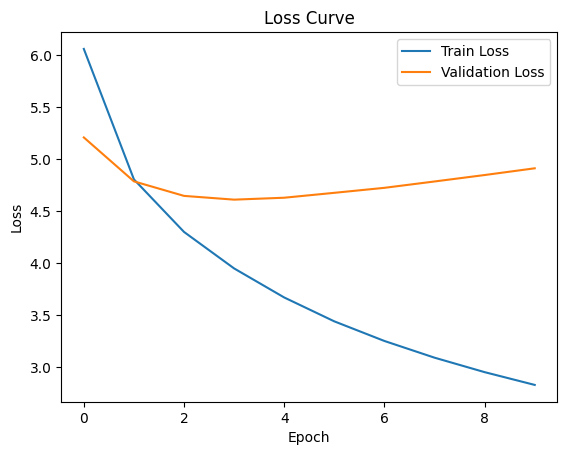

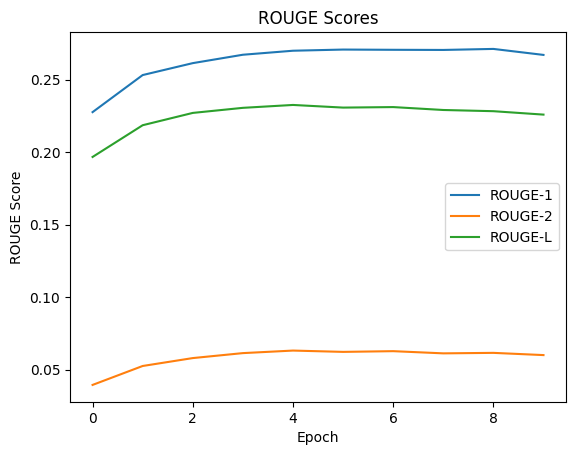

In [16]:
import matplotlib.pyplot as plt


plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()


rouge_1 = [score['rouge1'] for score in rouge_scores]
rouge_2 = [score['rouge2'] for score in rouge_scores]
rouge_L = [score['rougeL'] for score in rouge_scores]

plt.plot(rouge_1, label='ROUGE-1')
plt.plot(rouge_2, label='ROUGE-2')
plt.plot(rouge_L, label='ROUGE-L')
plt.xlabel('Epoch')
plt.ylabel('ROUGE Score')
plt.title('ROUGE Scores')
plt.legend()
plt.show()


<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">
مشاهده می‌شود که مقدار loss آموزش روند کاهشی و مقدار loss ارزیابی از جایی به بعد روند افزایشی را دارد که احتمالا به دلیل overfit شدن مدل است. اگرچه مقدار هر سه معیار ROUGE-1، ROUGE-2 و ROUGE-L تقریبا روندی افزایشی دارند.

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">



*بخش دوم:*

---

پاسح تشریحی قسمت (د):

---

# پاسخ خود را اینجا بنویسید:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px">
معیار ROUGE یک معیار ارزیابی برای مقایسه کیفیت خروجی‌های تولید شده توسط مدل‌ها (مانند با متن‌های مرجع است. این معیار دارای انواعی است که شامل ROUGE-N، ROUGE-L و ROUGE-S است. ROUGE-N به مقایسه n-gram ها بین خروجی مدل و متن مرجع می‌پردازد. ROUGE-1 برای مقایسه unigram ها و ROUGE-2  برای مقایسه bigram ها است. ROUGE-L بر اساس بزرگ‌ترین زیر دنباله مشترک  بین دو متن محاسبه می‌شود. در نهایت ROUGE-S که به مقایسه skip-bigram ها (زوج کلمات که ممکن است بین آن‌ها کلمات دیگری وجود داشته باشند) می‌پردازد. معیار ROUGE معمولاً با محاسبه Precision،Recall  و F1 score برای هر یک از انواع تعریف شده تعریف می‌شود. 
قدار معیار ROUGE معمولاً در بازه‌ای از 0 تا 1 قرار می‌گیرد، جایی که 1 به معنی تطابق کامل با متن مرجع است و 0 به معنی عدم تطابق با متن مرجع است.


---